### LECTURES 1+2: x86-64 Registers, Addressing, Arithmetic & Control Flow

THE BIG MENTAL SHIFT from Part I
   In Part I you worked with RISC-V -- a clean, regular ISA where every 
   instruction is 32 bits, there are 32 registers named `x0`-`x31`, 
   and the syntax is `op rd, rs1, rs2` (destination first). You also built the
   hardware that executes these instructions.

   x86-64 is the opposite of clean. It's a CISC architecture that has been 
   accumulating features since 1978. Instructions can be 1 to 15 bytes long. 
   There are only 16 general-purpose registers with weird historical names. The
   AT&T syntax puts the SOURCE FIRST, DESTINATION SECOND -- backwards from
   RISC-V. And arithmetic can operate directly on memory, not just registers.

   But here's the connection to Part I that makes it all click: the ISA is just 
   the contract between the programmer and the hardware. In Part I, you built 
   the hardware side of that contract for RISC-V. Now you're on the programmer
   side of a different contract -- x86-64. The concepts (registers, ALU
   operations, memory addressing, branches) are all the same; only the syntax
   and encoding details change.


THE 16 REGISTERS
   x86-64 has 16 general-purpose 64-bit integer registers. The first 8 have
   historical names from the 16-bit 8086 era; the last 8 were added when AMD 
   extended x86 to 64 bits:

   `%rax` (return value), `%rbx`, `%rcx`, `%rdx`, `%rsi`, `%rdi`, `%rsp`
   (stack pointer -- don't touch), `%rbp` (frame pointer -- optional in x86-64),
   `%r8` through `%r15`.

   The crucial thing is that each register has SUB-REGISTER names that access 
   smaller portions of the same physical. For example, `%rax` is the full 64
   bits, `%eax` is the bottom 32 bits, `%ax` is the bottom 16, `%al` is the 
   bottom 8. When you write to `%eax`, the top 32 bits `%rax` gets zeroed. When
   you write to `%ax` or `%al`, the upper bits are left unchanged. This 
   matters because the compiler picks the smallest suffix it can get away with 
   -- if your C code uses `int` (32 bits), you'll see `%eax`, `%edx`, etc., not 
   the 64-bit names.

   The other key fact: THE CALLING CONVENTION ASSIGNS SPECIFIC
   ROLES to those register, The first 6 integers 
   `%rdi, %rsi, %r`



---

   Think of calling a conention as a STANDARDISED CONTRACT between two functions
   . When one function (the Caller) wants to talk to another (the Callee), they
   don't just throw data into random registers. Instead, they agree on a 
   specific "seating chart" for data. In x86-64, the first six integer 
   arguments must sit in specific chairs: `%rdi`, `%rsi`, `%rdx`, `%rcx`, `%r8`,
   and finally `%r9`. If you have a seventh argument, there are no chairs left,
   so it has to wait out in the hallway (the Stack).

   The reason you see a move like `movl %edi, %eax` right at the start of a 
   function is becuase of ROLE TRANSITIONS. The value arrived in `%edi` because
   that is the "First Argument" bucket. However, the function likely wants to 
   do some math and eventually return a result. Since the contract states that 
   the RETURN VALUE must always be found in `%rax`, the code is essentially
   moving the input into the "Output" bucket so it can work on it directly and
   have it ready for the caller to find later. 

   This system exists to solve a massive logical problem: INTEROPERABILITY. 
   Without this contract, a programmer writing a library in C would have no idea 
   where a programmer using Python or Rust was going to put the arguments. By 
   mandating that the first argument is always written in `%rdi`, the compiler
   can generate code that works perfectly regardless of who is calling the
   function. It's like a universal language for the CPU's internal storage. 

   One final detail: you'll notice the change from `%rdi` (64-bit) to `%edi`
   (32-bit) or `rax` to `eax`. This is just the CPU being precise about DATA
   SIZE. If your function is handling a standard 4-byte `int`, it uses the `e`
   prefix versions. If it's handling a 8-byte `long` or a pointer, it uses the
   `r` prefix. The "bucket" is the same physical piece of silicon, but the name
   tells the CPU whether to use the whole bucket or just the bottom half. 

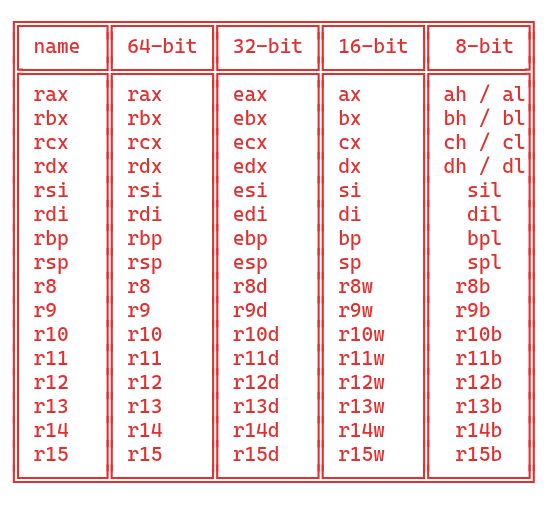

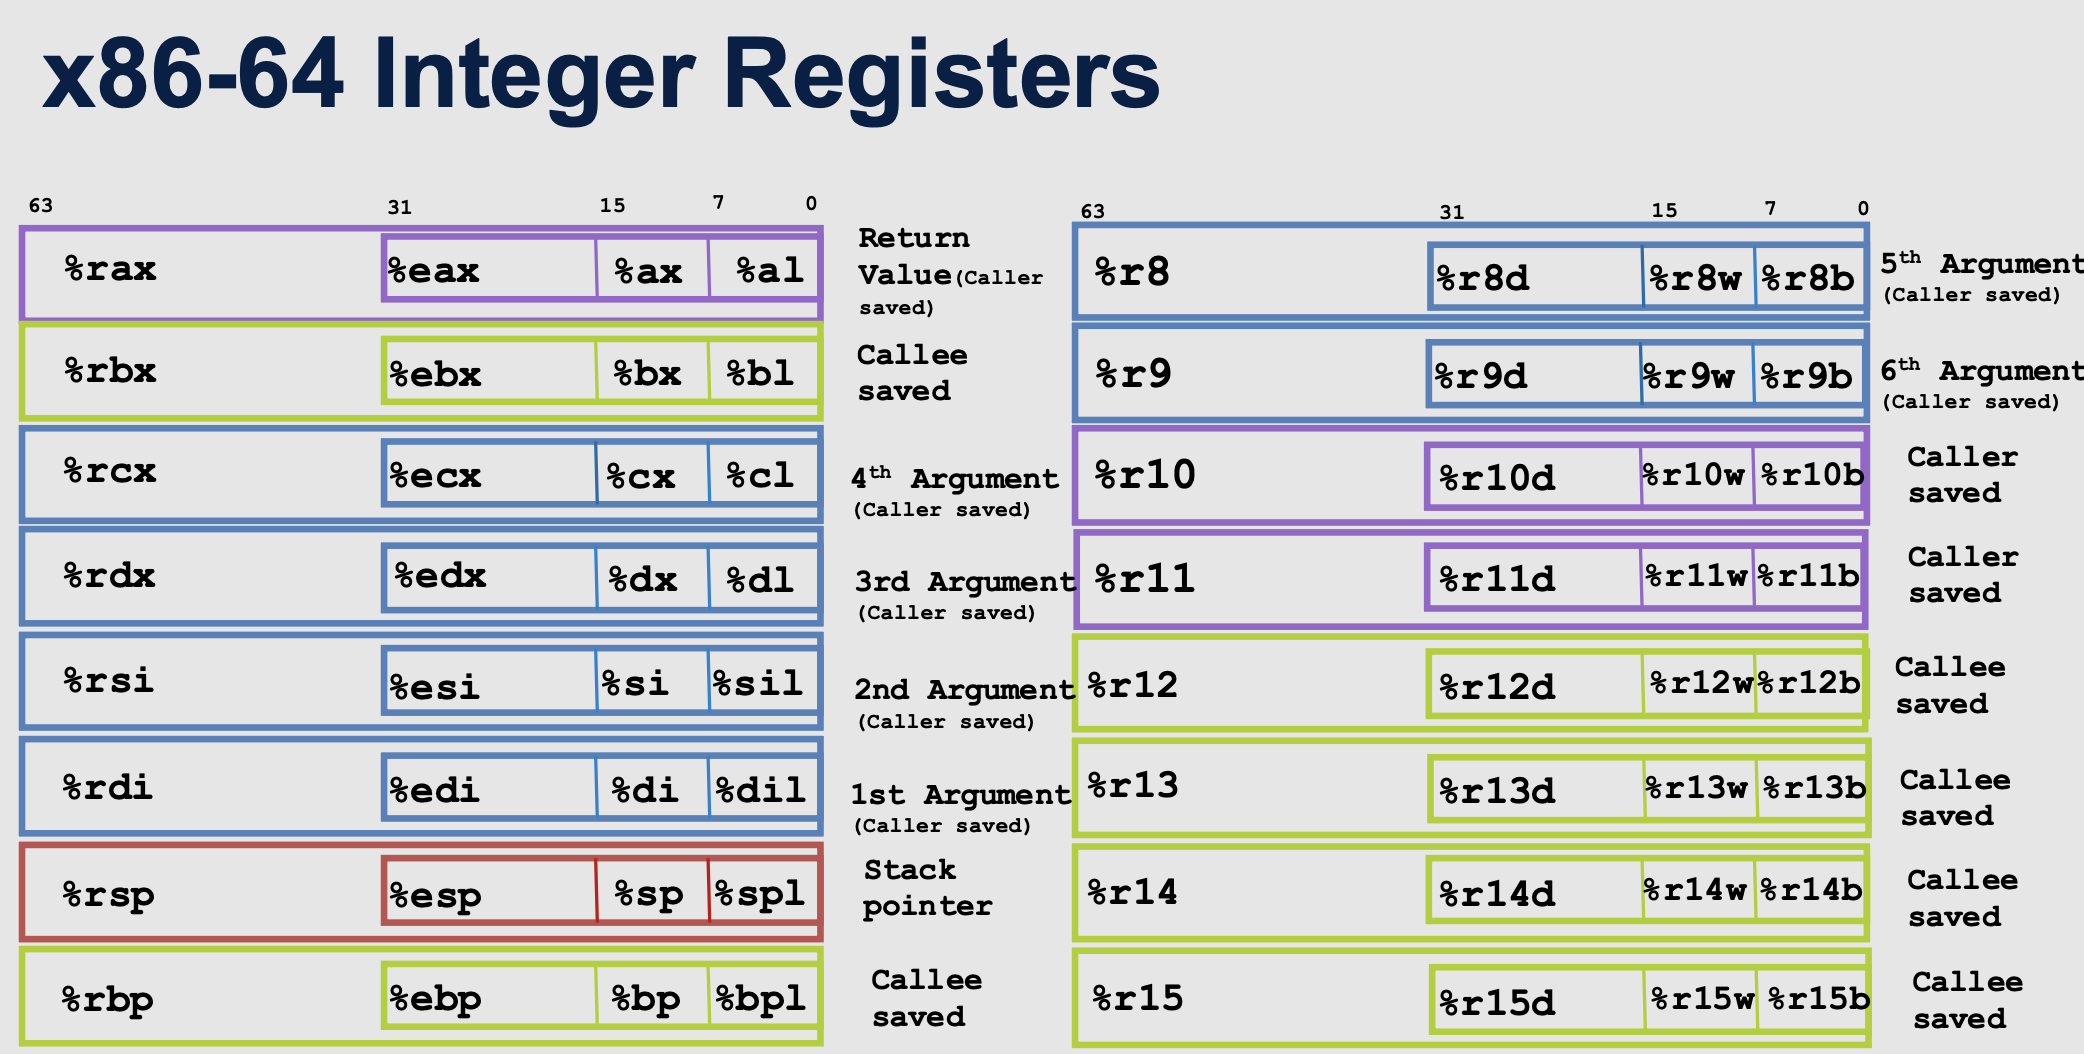

---

   In the world of x86-64 assembly, the difference between `%edi` and `eax`
   comes down to their ASSIGNED ROLES in the "Function Contract" (Calling
   Convention). 


1. THE ROLES: `%edi` vs. `%eax`
   - `%edi` (The input bucket): This is the register used to hold the FIRST
     INTEGER ARGUMENT passed to a function. If you call `my_function(10)`, the
     number `10` is placed into `%edi` before the function starts. Think of it
     as the "Incoming Mail" tray.
   - `%eax` (The Output Bucket): This is the register reserved for the RETURN
     VALUE. When a function finishes, the caller looks inside `%eax` to see what
     the result was. Think of it as the "Outgoing Mail" tray.


2. WHAT DOES `movl` DO?
   The `movl` instruction stands for MOVE LONG. 
   * MOVE: It copies data from a source to a destination. (It's actually a 
     "copy", as the source keeps its value).
   * LONG: The `l` suffix tells the CPU the data is 32 BITS (4 bytes) long. This
     matches the "e" prefix in the register names (like `%edi`), which
     represents the lower 32 bits of the full 64-bit register. 

3. Putting it together: `movl %edi, %eax`
   When you see this line at the start of a function, the code is saying: "Take
   the first argument that just arrived in the input tray (`%edi`) and copy it
   into the output tray (`%eax`)." If the function does nothing else and just 
   returnsm it effectively creates a "Mirror" function--whatever number you sent
   in is exactly what gets sent back out. 
        

---

### AT&T Syntax and Instruction Suffixes

   Transitioning from RISC-V to AT&T x86 syntax is famous for causing
   architectural whiplash! The biggest shock is the DIRECTION OF DATA FLOW. In
   RISC-V, you read right-to-left (`add x1, x2, x3`) means $x1 <- x2 + x3$, In
   AT&T x86, you read LEFT-TO-RIGHT (`addl %edx, %eax` means $eax <- eax + edx$)
   . The source is always first, and the destination is always last. Those 
   suffixes (b: 1 byte, w: 2 byte, l: 4 byte (long/double-word), q: 8 byte 
   (quad)) are just x86's way of strictly enforcing how big the data "bucket"
   is--so a `movq` (quadword) moves a full 64 bits, while a `movl` (long) moves
   32 bits. 

   Next, you have the prefixes that tell the assemler exactly what it is looking
   at. Because x86 is a CISC architecture with complex, variable-length 
   instrcutions, it has to be extremely explicit. A literal number must have a
   dollar sign (`$42`), and a register must have a percent sign (`%rax`). If 
   you forget the `$` and just write `42`, the CPU won't treat is as a number; 
   it will try to access memory address `0x0000002A`!

   The most powerful (and confusing) part of x86 is its MEMORY ADDRESSING MODE.
   In your RISC-V module, you only had `offset(base)`, like `8(x10)`. x86 gives
   you a full algebraic equation bakes right into the hardware: `Imm(rb, ri, s)`
   . This translates to `Base + (Index * Scale) + Offset`. This exists 
   specifically to make array looping incredibly fast. If you have an array of C
   `int` variables (which are 4 bytes each), you set the Scale to `4`, the Index
   of your loop counter `i`, and the Base to the start of the array. The CPU
   calculates the exact memory location in one single hardware step!

   Finally, the MEMORY-TO-MEMORY RULE. Even though x86 is a "Complex" 
   architecture that can do math directly on a memory address (which RISC-V
   strictly forbids), it still has physical limits. The datapath simply does
   not have enough wires to fetch a value from RAM, fetch another value from RAM
   , and write a result back to RAM all in one clock cycle. You must always use
   a register as a temporary "holding zone" to act as a bridge between two
   memory locations. 

`Imm(rb, ri, s)`

EXAMPLES AND UASAGE:
   - `4(%rbx)`: Effective address is `R[rbx] + 4` (Base + displacement)
   - `(, %rbx, 4)`: Effective address is `R[rbx] \times 4` (Scaled indexed).
   - `8(%rbp, %rdx, 4)`: Effective address is `8 + R[rbp] + R[rdx] \times 4`.

---

---

1. The `lea` Hack (Math without Memory)
   The `lea` (Load Effective Address) instruction is arguably the most famous
   "hack" in x86 architecture. Originally, it was designed to calculate a 
   complex memory address and save that address into a register so you could
   use it later. However, compiler writers quickly realised something briliant:
   the hardware that calculates `Base + (Index * Scale) + Offset` is incredibly
   fast. So, why actually go to memory at all?

   The compiler abuses `lea` to do three math operations (an addition, a 
   multiplication by a small constant, and adding another constant) all in a
   single clock cycle, completely bypassing RAM, It simply feeds numbers into 
   the memory-address calculator, but instead of using the result to look up a 
   RAM address, it just steals the final number and drops it straight into a 
   register.


2. BREAKING DOWN THE `lea` MATH
   When you look at the examples in your text, you can see how the compiler 
   turns the address equation into pure algebra. 
      - THE FREE ADDITION: `leal (%rdi, %rsi), %eax` translates to 
        `eax = rdi + rsi`. It uses `rdi` as the base and `rsi` as the index. 
      - THE MULTIPLY BY 3: `leal (%rsi, %rsi, 2), %eax` translates to 
        `eax = rsi + (rsi * 2)`. This equals `3 * rsi`.
      - THE COMBO MOVE: `leal 7(%rdx, %rdx, 4), %eax` translates to 
        `eax = rdx + (rdx * 4) + 7`. This gives you ``5 * rdx + 7` in one
        lightning-fast step! It replaces what would normally require an `imul`
        (multiply) and an `add` instruction.


3. Two-Operand Arithmetic & Shifts
   For standard math, x86 uses the `op source, destination` format. Again, the
   data flows left to right. If you see `subl %edx, %eax`, the CPU is taking the
   value in `eax`, subtracting `edx` from it, and saving the new result 
   back into `eax` (`eax -= edx`).

   The text also highlights SHIFT INSTRUCTIONS, which are another massive speed
   hack. Multiplying or dividing using the `imul` or `idiv` hardware takes
   several clock cycles. However, shifting binary bits left or right takes
   almost zero time. Shifting left by 4 (`sall $4, %edx`) adds four zeros to the
   binary number, which is the exact mathematical equivalent of multiplying by
   2^4 (16).


4. One-Operand Arithmetic
   Finally, you have unary operations that only need a single destination. 
   `incl` (increment) adds 1, `decl` (decrement) subtracts 1, `negl` (negate)
   flips the mathematical sign (like multiplying by -1), and `notl` flips 
   every binary `0` to a `1` and vice versa, These are short, fast, and 
   constantly used in `for` loops and `while` loops to tick the counter up or 
   down. 

In [ ]:
   ... In RISC-V, control flow is tightly coupled: an instruction like 
   `beq x1, x2, Target` does the subtraction, checks the Zero wire, and changes
   the PC all in one single clock cycle. x86, being a CISC architecture, 
   DECOUPLES this process. It breaks branching into two separate steps: first, 
   do some math to set the "Condition Code" flags, and second, use a Jump
   instruction that reads those flags to decide where to go. 

   The x86 ALU has a special status register that holds four critical flags, 
   which update automatically almost every time an arithmetic operation occurs.

   - ZF (Zero Flag): The exact same wire you saw in RISC-V. If the ALU outputs
     all zeros, this flag flips to 1. 
   - SF (Sign Flag): This is literally just a direct wire connected to the 
     MSB of the ALU result. In twos complement, if the MSB is 1, the number is
     negative. 
   - CF (Carry Flag): This detects UNSIGNED overflow. If you add two massive
     positive numbers and the result requires a 33rd bit (a carry out), this
     flag trips.
   - OF (Overflow Flag): This detects SIGNED overflow. It trips if the math
     breaks the rules of two's complement--for example, if you add two 
     positive numbers and the sign bit accidentally flips to 1 (negative), the
     hardware knows the result is corrupted.

   Because x86 relies on these flags for jumping, it needs a way to trigger them 
   without acicdentally destroying your data. Enter the "Ghost Operations": 
   `cmp` (Compare) and `test`. The `cmp a, b` instruction sends `b` and `a`
   through the ALU to perform subtraction (`b - a`), which updates all the flags
   , but then it simply throws the result in the trash instead of saving it to a
   register. This allows you to check if `a < b` (which sets the Sign Flag)
   withouts overwriting `b`.

   The `test` instruction does the exact same thing, but it performs a bitwise
   AND instead of subtraction. This brings us to the most famous idiom in x86
   assembly: `test %eax, %eax`. Mathematically, `X AND X` is just `X`. So, this
   instruction doesn't change the value, but if `%eax` happens to be 0, the ALU
   result is 0, which perfectly flips the ZERO FLAG (ZF) to 1. The very next
   line of code will usually be `je` (Jump if Equal / Jump is Zero), allowing
   the CPU to efficiently execute an `if (x == 0) statement!

---

   ... about how the CPU actually uses those four flags you just simulated to
   make decisions. 

   ...


1. Jumps (`jxx`) -- The Path Changes
   These are your standard `if` statements and loops. They look at the flags
   and decide whether to change the PC to a new address. 
      * The x86 quirk you must remember: it has different instructions for
        SIGNED vs. UNSIGNED comparisons. 
      * `jl` (Jump Less) is for signed numbers and checks the Sign and Overflow
        flags.
      * `jb` (Jump Below) is for unsigned numbers and simply checks the Carry
        flag. 


2. Sets (`setxx`) -- The Boolean Creators
   Sometimes you don't want to jump; you just want to know if something is true
   or false.

   If you write C code like `bool is_ready = (x < y);`, the CPU uses a `set`
   instruction. It checks the flags (like a jump would) but instead of moving 
   the PC, it just writes a `1` (true) or `0` false into a tiny 1-byte register.
   It's a fast, efficient way to evaluate logical expressions. 


3. CONDITIONAL MOVES (`cmovxx`) -- the Pipeline Saviors
   This is the hardware version of the ternary operatior (`result = condition ? a : b`).

   Remember the PIPELINE... If the CPU uses a standard Jump (`jxx`), it has to
   guess which way the branch will go to keep the pipeline full. If it guesses
   wrong (a. BRANCH MISPREDICTION), it has to flush the entire pipeline, 
   wasting many clock cycles. 

   A conditional move (`cmov`) completely solves this! It tells the CPU: 
   "If the flags are right, do a `mov`. If they are wrong, do absolutely 
   nothing." Because it never actually jumps to a new address, the pipeline 
   never has to guess, and you never suffer a misprediction penalty. Compilers
   will abuse `cmov` whenever possible to keep your code running at maximum
   speed. 

```c
void swap(int* xp, int* yp) {
    int t0 = *xp;
    int t1 = *yp;
    *xp = t1;
    *yp = t0;
}
```

```Assembly
movl (%rdi), %eax
movl (%rsi), %ebx
movl %ebx, (%rdi)
movl %eax, (%rsi)
```


---
   Syntax // What the Hardware Does // Use Case
   `%rax` // Use the literal value in the register // Simple variables/counters
   `(%rax)` // Go to address `rax` // Pointers
   `8(%rax)` // Go to address `rax + 8` // Accessing a field in a `struct`
   `(%rax, %rcx, 4)` // Go to address `rax + (rcx * 4)` // Accessing `array[i]` where each `int` is 4 bytes

   ...

...The only time those parentheses become "reundant" (mathematically speaking)
is with the `lea` instruction.

   - `movq 8(%rax), %rdx` -> Go to the RAM, get the data at `rax + 8`.
   - `leaq 8(%rax), %rdx` -> Just do the math `rax + 8` and save the result. DO
     NOT GO TO RAM. 


---
Quick Reference: Addressing Modes
```Assembly
$Imm
%reg
()
```

```c
int arith(int x, int y, int z) {
    int t1 = x + y;
    int t2 = z + t1; 
    int t3 = x + 4;
    int t4 = y * 48;
    int t5 = t3 + t4;
    int rval = t2 * t5;
    return rval;
}
```


Assembly (AT&T syntax: source, destination)
```Assembly
leal (%rdi, %rsi), %eax
addl %edx, %eax
leal (%rsi,%rsi,$2), %edx 
sall $4, %edx
leal 4(%rdi, %rdx), %ecx
imull %ecx, %eax
```


---

   ... to understand these, we need to look at "DIVISION CHOREOGRAPHY" in x86-64
   . Division is the most complex arithmetic operation. because it's the only 
   one that uses a "hardcoded" pair of registers and requires a special setup
   step.


---
1. `cltd` (Convert Long to Double-Long)
   In x86, the `idvl` instruction (32-bit division) doesn't just divide `%eax`.
   It actually divides a 64-bit BIT COMBINED VALUE stored across two registers:
   `%edx` (the high bits) and `%eax` (the low bits).

   `cltd` is a "helper" instruction. It takes the sign of `%eax` and copies it
   into every bit of `%edx`.

   * If `%eax` is positive: `%edx` becomes all `0`s.
   * If `%eax` is negative: `%edx` becomes all `1`s.

   WHY? Because if you don't do this, and `%edx` happens to have old "junk" data
   in it from a previous calculation, the `idivl` instruction will think you
   are trying to divide a massive, 64-bit monster number, and your result will
   be totally wrong. 


---
2. `idivl` (Signed Integer Divide)



```C
void cond(int x, int y, int z) {
    // x in %edi, y in %esi, z in %edx
    // result in esi
    if (x != 0) {#
        y = (y + z) / x;
    }
}
```

---

```Assembly
testl %edi, %edi                # Compute EDI AND EDI, set flags (is x zero?)
je .L2 (not taken)              # Jump to L2 if ZF=1 (skip division if x==0)
addl %edx, %esi                 # esi = y + z
movl %esi, %eax                 # Copy dividend to eax (idiv uses edx:eax)
ctld                            # Sign-extend eax into edx:eax (edx = sign bits)
idivl %edi                      # edx:eax / div -> quotient in eax, remainder in edx
.L2: (done)                     # End -- result (y+z) / x in %eax
```


            -- quotient in  `eax`
            -- remainder in `edx`

---

Dividend / Divisor = Quotient R Remainder


---


   In x86 assembly, specifically with the `idivl` (signed integer division, long)
   instruction, high bits and low bits refer to how a 64-bit dividend is split
   across two 32-bit registers--usually `%edx` (high bits) and `%eax` (low bits)
   . High bits carry the largest maginitude/sign, while low bits carry the least
   significant numerical value.


KEY CONCEPTS IN `idivl` (32-bit Division)
   - THE 64-BIT DIVIDEND (`%edx:%eax`): To divide a large number, `idivl` uses a
     pair of 32-bit registers, `edx` and `eax`, combined to act as a 64-bit
     registers (a "quadword").
   - High Bits (`%edx`): Contains the "most significant" bits of the 64-bit 
     dividend. In signed division, this often holds the sign extension (0 for
     positive, -1/0xFFFFFFFF for negative).
   - Low Bits (`%eax`): Contains the "least significant" 32 bits of the 64-bit
     dividend.
   - `idivl` Action: It divides the 64-bit value `(%edx << 32) | %eax` by the
     specified 32-bt operand. 
   - RESULT: The quotient is stored in `%eax` and the remainder in `%edx`.


...
   Without properly setting the high bits in `%edx` (e.g., leaving garbage data)
   , the division will yield an incorrect result or an overflow exception.    



---

3. `.L2` and `(not taken)` / `(done)`
   These are CONTROL FLOW markers usually seen in a compiler's assembly output
   or a debugger (like `gdb` or `objdump`).
   
   * `.L2` (Local Label): This is just a "address marker" or a "bookmark". It's
     a destination for a jump. For example, `jne .L2` tells the CPU: "if the
     last comparison wasn't equal, teleport the PC to line labeled `.L2`."
   * `(not taken)` / `(done)`: These are ANNOTATIONS provided by your debugger
     or profiler.
      * `(not taken)` means that during the last time the code ran, the CPU
        reached a jump instruction but decided NOT to jump (the condition was
        false).
      * `(done)` simply marks the end of a trace of the point where the debugger
        stopped stepping.   

### Concrete Example
   If you write `int result = 10 / 3;` in C, the assembly looks like this:

```Assembly
movl  $10, %eax         # Put 10 into the "Low" register
ctld                    # Sign-extend into %edx (%edx is now 0)
movl  $3, %ecx          # Put the divisor (3) into %ecx
idivl %ecx              # Divide edx:eax (10) by ecx (3)
```                     # RESULT: %eax = 3, %edx = 1 (the remainder)


How else is this normally used?
   The most common "trick" is using the remainder in `%edx` for the MODULO
   OPERATOR (`%`). If you see an `idivl` followed immediately by a 
   `movl %edx, %eax`, the compiler is actually performing `x % y` rather than
   `x / y`.

---

### addressing modes (all forms)
   Demonstrates every addressing mode form: immediate, register, direct, 
   indirect, displacement, indexed, scaled

```C
// Not real C - this demonstrates all addressing modes
// Array A at 0x100: [10, 20, 30, 40, 50]
// Each element is 4 bytes (int)
```
   

```Assembly
movl $99, %eax              # Immediate --> Registers
movl (%rbx), %edx           # Indirect: Mem[%rbx]
movl 8(%rbx), %edx          # Displacement: Mem[%rbx + 8]
movl (%rbx, %rcx, 4), %edx  # Indexed+scaled: Mem[%rbx + 4 * %rcx]
movl 4(%rbx, %rcx, 4), %esi # Full form: Mem[%rbx + 4 * %rcx + 4]
leal (%rbx, %rcx, 4), %eax  # LEA: compute address, don't load!
```

-- Bitwise operators `&` (AND) and `|` (OR) compare integers at the binary level
   (bit=-by-bit). The `&` operator returns 1 if BOTH bits are 1, while `|` 
   returns 1 if EITHER or BOTH bits are 1. These operators are used to 
   manipulate specific bits (masking) and perform fast, low-level computations. 

---

```c
int min(int x, int y) {
    return x < y ? x : y;
}
```
   
   return x < y ? x : y -- min() using conditional move instead of branching

```assembly
movl %esi, %eax
cmpl %edi, %esi         # Compare: compute `esi - edi`, set flags
cmovl %edi, %eax        # If esi < edi (SF != OF), move `%edi` into `%eax`
```

-- The carry flag (CF) in assembly is triggered when an unsigned arithmetic
   operation produces a result too large or too small (negative) to fit into
   the destination register, indicating unsigned overflow or a borrow. ...